In [128]:
import os
import time
import random
import numpy as np
import torch 
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as data
import torchvision
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torchsummary import summary
import matplotlib.pyplot as plt
from PIL import Image



## Tải tập dataset

In [129]:
ROOT = './data'
train_data = datasets.MNIST(
    root=ROOT,
    train=True,
    download=True,
)
test_data = datasets.MNIST(
    root=ROOT,
    train=False,
    download=True
)


## Tiền xử lý dữ liệu

In [130]:
valid_ratio = 0.9
n_train_example = int(len(train_data) * valid_ratio)
n_valid_example = len(train_data) - n_train_example
print(n_train_example,n_valid_example)
train_data,valid_data = data.random_split(train_data, [n_train_example,n_valid_example])

mean = train_data.dataset.data.float().mean()/255
std = train_data.dataset.data.float().std()/255
print(mean,std)
train_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[mean],std=[std])
])
test_transforms=transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[mean],std=[std])
])

train_data.dataset.transform = train_transforms
valid_data.dataset.transform = test_transforms
print(train_data, valid_data)

54000 6000
tensor(0.1307) tensor(0.3081)
<torch.utils.data.dataset.Subset object at 0x000001AFB321EA90> <torch.utils.data.dataset.Subset object at 0x000001AFB3168ED0>


In [131]:
BATCH_SIZE = 256
train_dataloader = data.DataLoader(
    train_data,
    shuffle = True,
    batch_size = BATCH_SIZE
)
valid_dataloader = data.DataLoader(
    valid_data,
    batch_size = BATCH_SIZE
)

## Tạo mô hình LeNet

In [132]:
class LeNetClassifier(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.conv1 = nn.Conv2d(
            in_channels = 1, out_channels = 6, kernel_size =5, padding='same'
        )
        self.avgpool1 = nn.AvgPool2d(kernel_size=2)
        self.conv2 = nn.Conv2d(in_channels=6,out_channels = 16, kernel_size=5)
        self.avgpool2 = nn.AvgPool2d(kernel_size=2)
        self.flatten = nn.Flatten()
        self.fc_1 = nn.Linear(16 * 5 * 5, 120)
        self.fc_2 = nn.Linear(120,84)
        self.fc_3=nn.Linear(84,num_classes)

    def forward(self,inputs):
        outputs = self.conv1(inputs)
        outputs = self.avgpool1(outputs)
        outputs = F.relu(outputs)
        outputs = self.conv2(outputs)
        outputs = self.avgpool2(outputs)
        outputs = F.relu(outputs)
        outputs = self.flatten(outputs)
        outputs = self.fc_1(outputs)
        outputs = self.fc_2(outputs)
        outputs = self.fc_3(outputs)
        return outputs

## Training 

In [133]:
def train(model, optimizer, criterion, train_dataloader, device, epoch=0, log_interval
=50):
    model.train()
    total_acc, total_count = 0, 0
    losses = []
    start_time = time.time()

    for idx, (inputs, labels) in enumerate(train_dataloader):
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        predictions = model(inputs)
    # compute loss
        loss = criterion(predictions, labels)
        losses.append(loss.item())
    # backward
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 0.1)
        optimizer.step()
        total_acc += (predictions.argmax(1) == labels).sum().item()
        total_count += labels.size(0)
        if idx % log_interval == 0 and idx > 0:
            elapsed = time.time()- start_time
            print(
                "| epoch {:3d} | {:5d}/{:5d} batches "
                "| accuracy {:8.3f}".format(
                    epoch, idx, len(train_dataloader), total_acc / total_count
                )
            )
            total_acc, total_count = 0, 0
            start_time = time.time()
        
    epoch_acc = total_acc / total_count
    epoch_loss = sum(losses) / len(losses)
    return epoch_acc, epoch_loss

 # Evaluation function
def evaluate(model, criterion, valid_dataloader):
    model.eval()
    total_acc, total_count = 0, 0
    losses = []

    with torch.no_grad():
        for idx, (inputs, labels) in enumerate(valid_dataloader):
            inputs = inputs.to(device)
            labels = labels.to(device)

            predictions = model(inputs)

            loss = criterion(predictions, labels)
            losses.append(loss.item())

            total_acc += (predictions.argmax(1) == labels).sum().item()
            total_count += labels.size(0)

    epoch_acc = total_acc / total_count
    epoch_loss = sum(losses) / len(losses)
    return epoch_acc, epoch_loss

In [137]:
num_classes = len(train_data.dataset.classes)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'🖥️  Training on: {device}')

if torch.cuda.is_available():
    print(f'GPU Name: {torch.cuda.get_device_name(0)}')
    print(f'GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB')
else:
    print('GPU not available, using CPU')
lenet_model = LeNetClassifier(num_classes)
lenet_model.to(device)

criterion = torch.nn.CrossEntropyLoss()
optimizer = optim.Adam(lenet_model.parameters())

num_epochs = 10
save_model = './model'
if not os.path.exists(save_model):
    os.makedirs(save_model)
train_accs, train_losses = [], []
eval_accs, eval_losses = [], []
best_loss_eval = 100

for epoch in range(1, num_epochs+1):
    epoch_start_time = time.time()
# Training
    train_acc, train_loss = train(lenet_model, optimizer, criterion, train_dataloader,
device, epoch)
    train_accs.append(train_acc)
    train_losses.append(train_loss)

# Evaluation
    eval_acc, eval_loss = evaluate(lenet_model, criterion, valid_dataloader)
    eval_accs.append(eval_acc)
    eval_losses.append(eval_loss)

# Save best model
    if eval_loss < best_loss_eval:
        torch.save(lenet_model.state_dict(), save_model + '/lenet_model.pt')

 # Print loss, acc end epoch
    print("-" * 59)
    print(
        "| End of epoch {:3d} | Time: {:5.2f}s | Train Accuracy {:8.3f} | Train Loss{:8.3f} "
        "| Valid Accuracy {:8.3f} | Valid Loss {:8.3f} ".format(epoch, time.time()- epoch_start_time, train_acc, train_loss, eval_acc,eval_loss)
    )
    print("-" * 59)
# Load best model
    lenet_model.load_state_dict(torch.load(save_model + '/lenet_model.pt'))
    lenet_model.eval()

🖥️  Training on: cpu
GPU not available, using CPU
| epoch   1 |    50/  211 batches | accuracy    0.644
| epoch   1 |   100/  211 batches | accuracy    0.891
| epoch   1 |   150/  211 batches | accuracy    0.930
| epoch   1 |   200/  211 batches | accuracy    0.944
-----------------------------------------------------------
| End of epoch   1 | Time: 18.91s | Train Accuracy    0.956 | Train Loss   0.481 | Valid Accuracy    0.950 | Valid Loss    0.170 
-----------------------------------------------------------
| epoch   2 |    50/  211 batches | accuracy    0.955
| epoch   2 |   100/  211 batches | accuracy    0.963
| epoch   2 |   150/  211 batches | accuracy    0.967
| epoch   2 |   200/  211 batches | accuracy    0.970
-----------------------------------------------------------
| End of epoch   2 | Time: 18.58s | Train Accuracy    0.969 | Train Loss   0.119 | Valid Accuracy    0.967 | Valid Loss    0.111 
-----------------------------------------------------------
| epoch   3 |    5

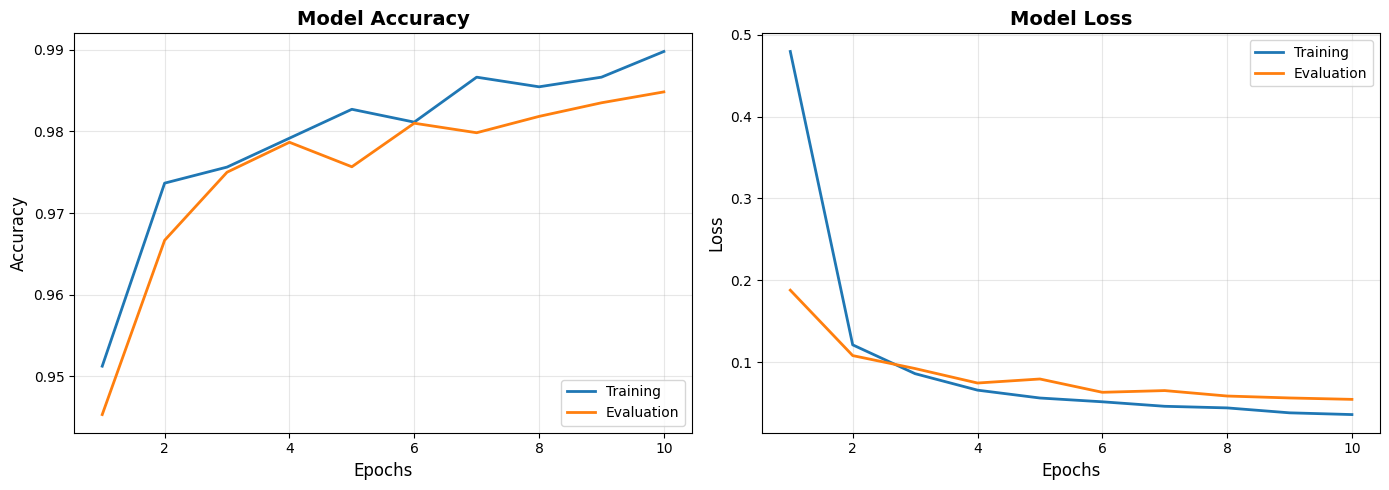

In [135]:
# Plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot Accuracy
ax1.plot(range(1, num_epochs + 1), train_accs, label='Training', color='#1f77b4', linewidth=2)
ax1.plot(range(1, num_epochs + 1), eval_accs, label='Evaluation', color='#ff7f0e', linewidth=2)
ax1.set_xlabel('Epochs', fontsize=12)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.set_title('Model Accuracy', fontsize=14, fontweight='bold')
ax1.legend(loc='lower right')
ax1.grid(True, alpha=0.3)

# Plot Loss
ax2.plot(range(1, num_epochs + 1), train_losses, label='Training', color='#1f77b4', linewidth=2)
ax2.plot(range(1, num_epochs + 1), eval_losses, label='Evaluation', color='#ff7f0e', linewidth=2)
ax2.set_xlabel('Epochs', fontsize=12)
ax2.set_ylabel('Loss', fontsize=12)
ax2.set_title('Model Loss', fontsize=14, fontweight='bold')
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [136]:
test_data.transform = test_transforms
test_dataloader = data.DataLoader(
    test_data,
    batch_size=BATCH_SIZE
)
test_acc, test_loss = evaluate(lenet_model, criterion, test_dataloader)
test_acc, test_loss

(0.9872, 0.04737196259302436)

In [138]:
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
else:
    print("⚠️ PyTorch không hỗ trợ CUDA - cần cài lại PyTorch phiên bản có CUDA")

⚠️ PyTorch không hỗ trợ CUDA - cần cài lại PyTorch phiên bản có CUDA
